In [37]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report,
)

## Dataset load & EDA

In [38]:
df = pd.read_csv('data.csv')
df.head()

,user_id,age,gender,device_type,time_on_site,pages_viewed,previous_purchases,cart_items,discount_seen,ad_clicked,returning_user,avg_session_time,bounce_rate,purchase
0,1.0,56.0,Female,Desktop,12.90,8.0,13.0,1.0,1.0,NaN,0.0,6.97,28.18,1.0
1,2.0,46.0,Male,Mobile,15.63,9.0,4.0,6.0,1.0,1.0,1.0,19.17,86.73,1.0
2,3.0,32.0,Female,NaN,11.64,12.0,11.0,0.0,0.0,0.0,1.0,8.87,83.09,1.0
3,4.0,25.0,Female,Mobile,22.71,5.0,10.0,1.0,0.0,0.0,1.0,NaN,79.03,1.0
4,5.0,38.0,Female,Mobile,26.35,9.0,12.0,4.0,1.0,0.0,0.0,18.15,55.35,1.0


In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   user_id             7840 non-null   float64
 1   age                 7840 non-null   float64
 2   gender              7840 non-null   str    
 3   device_type         7840 non-null   str    
 4   time_on_site        7840 non-null   float64
 5   pages_viewed        7840 non-null   float64
 6   previous_purchases  7840 non-null   float64
 7   cart_items          7840 non-null   float64
 8   discount_seen       7840 non-null   float64
 9   ad_clicked          7840 non-null   float64
 10  returning_user      7840 non-null   float64
 11  avg_session_time    7840 non-null   float64
 12  bounce_rate         7840 non-null   float64
 13  purchase            7840 non-null   float64
dtypes: float64(12), str(2)
memory usage: 963.6 KB


In [40]:
df.isna().sum()
df = df.dropna()

In [41]:
df.isna().sum()

user_id               0
age                   0
gender                0
device_type           0
time_on_site          0
pages_viewed          0
previous_purchases    0
cart_items            0
discount_seen         0
ad_clicked            0
returning_user        0
avg_session_time      0
bounce_rate           0
purchase              0
dtype: int64

In [42]:
df.shape

(6019, 14)

In [43]:
size_map = {'Male' : 0, 'Female' : 1}
df['gender'] = df['gender'].map(size_map)
size_map = {'Desktop' : 0, 'Mobile' : 1, 'Tablet' : 2}
df['device_type'] = df['device_type'].map(size_map)

df = df.drop(columns=['user_id'])

In [44]:
df.head()

,age,gender,device_type,time_on_site,pages_viewed,previous_purchases,cart_items,discount_seen,ad_clicked,returning_user,avg_session_time,bounce_rate,purchase
1,46.0,0,1,15.63,9.0,4.0,6.0,1.0,1.0,1.0,19.17,86.73,1.0
4,38.0,1,1,26.35,9.0,12.0,4.0,1.0,0.0,0.0,18.15,55.35,1.0
5,56.0,1,0,26.60,1.0,12.0,7.0,1.0,1.0,0.0,28.40,13.90,1.0
6,36.0,0,1,7.60,11.0,11.0,6.0,1.0,1.0,1.0,4.51,13.12,1.0
7,40.0,1,1,26.98,7.0,5.0,2.0,1.0,0.0,0.0,33.34,12.61,1.0


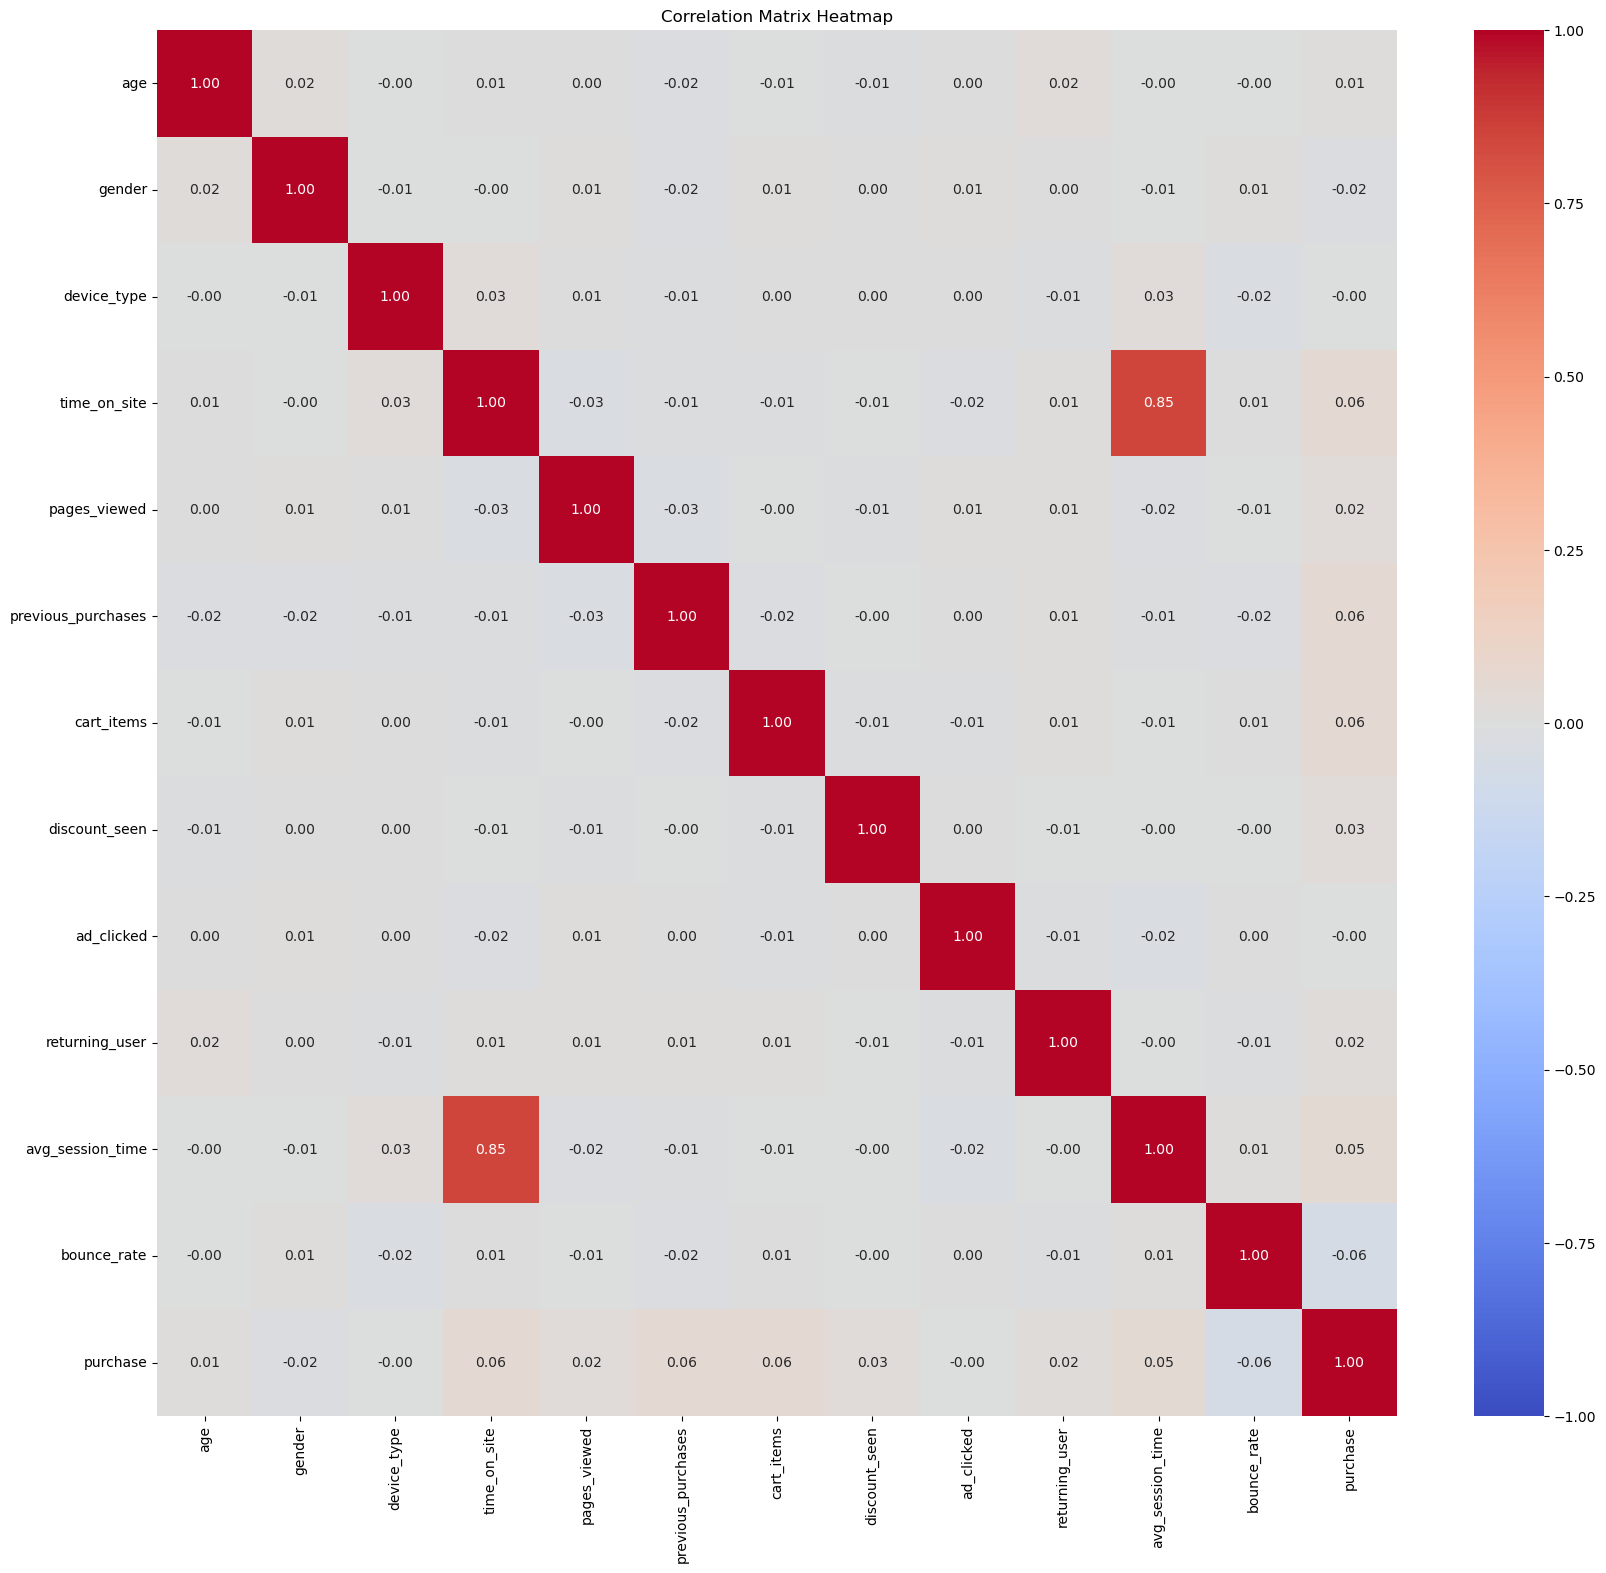

In [45]:
corr = df.corr()

plt.figure(figsize=(20, 18))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation Matrix Heatmap")
plt.show()

### Выбор и построение модели

In [46]:
X = df.iloc[:, 0:12]
y = df.iloc[:, 12]
X = StandardScaler().fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42)

In [60]:
param_grid = {
    'C' : [0.01, 0.1, 1, 10, 100],
}
logreg = GridSearchCV(estimator = LogisticRegression(penalty = 'l2'), param_grid = param_grid, scoring='roc_auc')
logreg.fit(X_train, y_train)
print(logreg.best_score_)
logreg = logreg.best_estimator_

0.9992230854605992


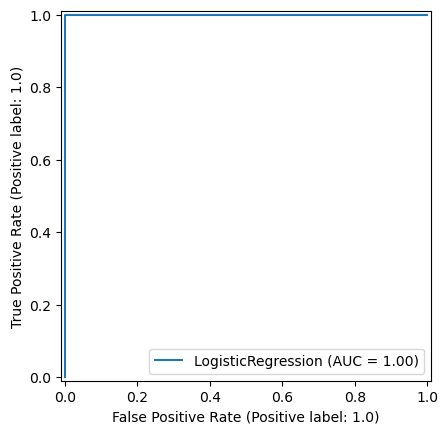

In [61]:
RocCurveDisplay.from_estimator(logreg, X_test, y_test)
plt.show()
